# 01 - Exploratory Data Analysis (EDA)

## Dataset: SECOM Semiconductor Manufacturing Data
- **Source:** UCI Machine Learning Repository
- **Chips tested:** 1567
- **Original features:** 590
- **Labels:** -1 (Fail), 1 (Pass) → remapped to 0 and 1

## Key Findings
- 41,951 missing values across 538 columns
- 28 columns dropped (>50% missing)
- 116 columns dropped (zero variance)
- **Final clean features:** 446
- **Class distribution:** 1463 Fail (93.36%) vs 104 Pass (6.64%)
- Severe class imbalance — accuracy is not a valid metric here

## Decisions Made
1. Drop columns with >50% missing data
2. Fill remaining missing values with column median
3. Drop zero variance columns
4. Remap labels from {-1, 1} to {0, 1}

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/secom.data', sep=' ', header=None)
labels = pd.read_csv('../data/raw/secom_labels.data', sep=' ', header=None)

print("Dataset Shape:", df.shape)
print("Labels Shape:", labels.shape)

Dataset Shape: (1567, 590)
Labels Shape: (1567, 2)


In [3]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 590 entries, 0 to 589
dtypes: float64(590)
memory usage: 7.1 MB


In [5]:
labels.head(10)

,0,1
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00
5,-1,19/07/2008 17:53:00
6,-1,19/07/2008 19:44:00
7,-1,19/07/2008 19:45:00
8,-1,19/07/2008 20:24:00
9,-1,19/07/2008 21:35:00


In [6]:
# Count missing values per column
missing = df.isnull().sum()
print("Total missing values:", missing.sum())
print("Columns with no missing values:", (missing == 0).sum())
print("Columns with missing values:", (missing > 0).sum())

Total missing values: 41951
Columns with no missing values: 52
Columns with missing values: 538


In [7]:
# What percentage of each column is missing?
missing_percent = (df.isnull().sum() / len(df)) * 100

print("Columns missing more than 50% of data:", (missing_percent > 50).sum())
print("Columns missing more than 90% of data:", (missing_percent > 90).sum())

# Show the worst 10 columns
print("\nTop 10 most incomplete columns:")
print(missing_percent.sort_values(ascending=False).head(10))

Columns missing more than 50% of data: 28
Columns missing more than 90% of data: 4

Top 10 most incomplete columns:
157    91.193363
292    91.193363
293    91.193363
158    91.193363
492    85.577537
358    85.577537
85     85.577537
220    85.577537
246    64.964901
109    64.964901
dtype: float64


In [ ]:
# Drop columns with more than 50% missing
threshold = 50
cols_to_drop = missing_percent[missing_percent > threshold].index
df_cleaned = df.drop(columns=cols_to_drop)

print(f"Columns dropped: {len(cols_to_drop)}")
print(f"Remaining columns: {df_cleaned.shape[1]}")

Columns dropped: 28
Remaining columns: 562


In [ ]:
# Filling remaining missing values with median
df_cleaned = df_cleaned.fillna(df_cleaned.median())

print("Missing values remaining:", df_cleaned.isnull().sum().sum())

Missing values remaining: 0


In [ ]:
# Droping zero variance columns (same value for every chip)
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)
selector.fit(df_cleaned)

cols_before = df_cleaned.shape[1]
df_cleaned = df_cleaned.loc[:, selector.get_support()]
cols_after = df_cleaned.shape[1]

print(f"Zero variance columns dropped: {cols_before - cols_after}")
print(f"Final number of features: {df_cleaned.shape[1]}")

Zero variance columns dropped: 116
Final number of features: 446


In [13]:
# Cell - Prepare the labels
labels.columns = ['label', 'timestamp']
print(labels['label'].value_counts())

label
-1    1463
 1     104
Name: count, dtype: int64


In [15]:
print(labels['label'].value_counts())
print(labels['label'].unique())

label
-1    1463
 1     104
Name: count, dtype: int64
[-1  1]


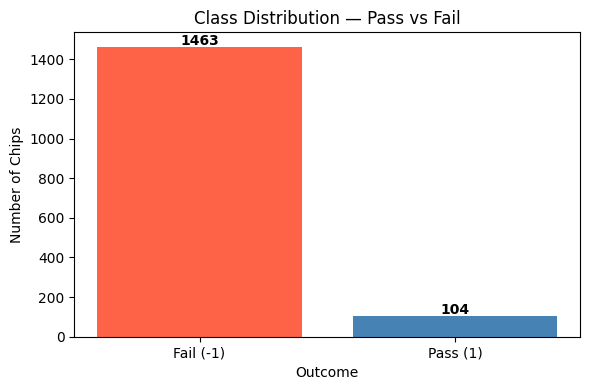

Fail rate: 93.36%
Pass rate: 6.64%


In [ ]:
#Visualization
counts = labels['label'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(['Fail (-1)', 'Pass (1)'], 
        [counts[-1], counts[1]], 
        color=['tomato', 'steelblue'])
plt.title('Class Distribution — Pass vs Fail')
plt.ylabel('Number of Chips')
plt.xlabel('Outcome')

for i, v in enumerate([counts[-1], counts[1]]):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/class_distribution.png', dpi=150)
plt.show()

print(f"Fail rate: {counts[-1]/len(labels)*100:.2f}%")
print(f"Pass rate: {counts[1]/len(labels)*100:.2f}%")

In [17]:
# Rename label column and extract just the label
y = labels['label'].copy()

# Convert labels to 0 and 1 (standard ML convention)
# -1 (fail) becomes 0, 1 (pass) stays 1
y = y.map({-1: 0, 1: 1})

print("Label distribution after remapping:")
print(y.value_counts())
print(f"\n0 = Fail, 1 = Pass")

Label distribution after remapping:
label
0    1463
1     104
Name: count, dtype: int64

0 = Fail, 1 = Pass


In [ ]:
X = df_cleaned.copy()

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Features shape: (1567, 446)
Labels shape: (1567,)


In [ ]:
X.to_csv('../data/processed/secom_features_cleaned.csv', index=False)
y.to_csv('../data/processed/secom_labels_cleaned.csv', index=False)